# 🧪 Laboratoire : Estimation de la pression sanguine à partir des du signal PPG

**🎯 Objectif général du laboratoire**
Ce laboratoire vise à estimer automatiquement les valeurs systolique (SBP) et diastolique (DBP) de la pression artérielle à partir du seul signal PPG, en s’appuyant sur des enregistrements de soins intensifs. Les mesures invasives de pression artérielle (ABP) serviront de vérité terrain.

Nous travaillerons avec la base **MIMIC-III Waveform Matched Subset**, disponible sur PhysioNet, qui contient des enregistrements physiologiques continus incluant :
* PPG/PLETH (photopléthysmographie)
* ABP/ART (pression artérielle invasive)

🔧 Téléchargement (Python, local) : dans cet exercice, nous allons télécharger des données depuis PhysioNet, les sauvegarder localement, puis travailler avec elles: 
🔗 https://physionet.org/content/mimic3wdb-matched/1.0/

**📁 Où trouver le PPG et l’ABP ?**
Chaque séjour possède généralement :
* un waveform record (fichiers .dat + .hea) avec plusieurs canaux :
  * PPG souvent nommé PLETH,
  * ABP (invasif) nommé ABP ou ART,
  * autres (ECG, RESP, etc.).
    Les waveforms sont typiquement échantillonnés à ~125 Hz. 
* Toutes les données ne contiennent pas tous les canaux. Chaque fichier de données doit être vérifié..
Remarque – Organisation : dans MIMIC-III Matched Subset, les enregistrements sont regroupés par dossiers (pXX/...) ; chaque enregistrement possède un header .hea listant les noms de canaux (repérez PLETH pour PPG et ABP/ART pour la pression).

**🧠 Rappel : PPG, pression artérielle et ABP (MIMIC)**

**Qu’est-ce que la PPG ?**
La photopléthysmographie (PPG) est une technique optique non invasive qui mesure les variations d’absorption lumineuse liées aux changements de volume sanguin pulsatile. Elle est omniprésente en clinique et dans les wearables.
La PPG est le plus souvent mesurée au niveau des doigts, des poignets, des lobes d'oreille et du front. Dans l'ensemble de données MIMIC, les données sont enregistrées au niveau du bout des doigts.

**Comment la PPG est liée à la pression artérielle ?**
Les variations de la pression artérielle se reflètent dans la morphologie du pouls PPG : amplitude pulsatile, temps de montée systolique, encoche dicrote, indices dérivés, ainsi que des mesures temporelles (ex. PAT/PTT lorsqu’on dispose d’un ECG). Ces caractéristiques sont exploitées pour estimer SBP/DBP à partir du PPG, via des méthodes statistiques ou d’apprentissage automatique.
ABP dans MIMIC : quelle “vérité terrain” utilisons-nous ?
Dans MIMIC, la pression artérielle invasive (ABP) est mesurée en continu via un cathéter intra-artériel (souvent radial), relié à un transducteur et enregistré par les moniteurs en soins intensifs.
* Le canal ABP ou ART fournit l'onde continue (mmHg) à partir de laquelle les valeurs systoliques (PAS/SBP) et diastoliques (PAD/DBP) peuvent être extraites.
* Ces mesures constituent la référence clinique pour l’évaluation de la pression.

**Remarque pratique :** les signaux peuvent contenir des artéfacts (rinçage, déconnexion, amortissement). Avant d’extraire les cibles SBP/DBP, il est recommandé de vérifier la qualité des ondes ABP et du PPG.

**Remarque :** L'estimation de la pression artérielle ou de ses valeurs maximales et minimales à chaque battement cardiaque, représentées par la pression artérielle systolique (PAS/SBP) et diastolique (PAD/DBP), à partir de la PPG offre une méthode non invasive, continue et potentiellement sans brassard pour la surveillance de la pression artérielle, ce qui constitue une amélioration significative par rapport aux mesures traditionnelles, intermittentes et souvent inconfortables à l'aide d'un brassard. Cette approche pourrait permettre une surveillance à long terme et en temps réel de la santé cardiovasculaire grâce à des appareils portables.

# 💻 Exercice 1 – Visualisation et filtrage

**✍️  1.1. Rechercher un fichier de données contenant des mesures synchronisées de PPG et d'ABP**

1.	Recherchez dans le répertoire de données MIMIC et trouvez un enregistrement qui contient à la fois ABP et PPG (vous verrez de nombreux enregistrements, chacun avec des modalités de signal différentes et des données manquantes). Vous pouvez utiliser l'interface Web :

🔗 https://physionet.org/lightwave/?db=mimic3wdb-matched/1.0

**✍️Tracez** tous les canaux de cet enregistrement.

**❗️Remarque :** votre enregistrement doit être différent de celui de la partie 2 de cet exercice (p04/p046223/3729975_0001).


In [ ]:
!pip install numpy
!pip install wfdb

In [ ]:
import numpy as np
import wfdb
import matplotlib.pyplot as plt

In [ ]:
record_path = r"C:\Users\moham\Desktop\Desktop\s7 Automne 2025\GTS880\Lab2\lab2p1\3193799_0001"

# Lire l'en tête (.hea) et les données (.dat)
header = wfdb.rdheader(record_path)

record = wfdb.rdrecord(record_path) 

fs = record.fs
t = np.arange(record.sig_len) / fs

### Explication du code

`record` : objet retourné par `wfdb.rdrecord(record_path)`.

Il contient :
* `record.p_signal` → matrice de signaux (chaque colonne = un canal)
* `record.sig_name` → liste des noms de canaux
* `record.fs` → fréquence d’échantillonnage
* `record.n_sig` → nombre total de canaux (ou signaux)

`t = np.arange(record.sig_len) / record.fs` sert à créer le vecteur temps correspondant aux échantillons du signal (pour l’axe des x dans ton tracé).
* `record.sig_len` C’est le nombre total d’échantillons dans le signal
* `np.arange(n)` crée un tableau de 0 à n−1
* En divisant chaque indice par `record.fs`, tu convertis ces indices en secondes


`plt.subplot(a, b, c)` divise ta figure en une grille de sous-graphes :
* a = nombre de lignes
* b = nombre de colonnes
* c = indice du sous-graphe actif (celui où tu veux tracer)

In [ ]:
# Tracer tous les canaux
n = record.n_sig # On récupère le nombre total de canaux dans le fichier
plt.figure(figsize=(12, 2.5 * n)) # Crée une figure matplotlib assez haute pour afficher tous les signaux l’un sous l’autre (2.5 pouces de hauteur par canal)
for i in range(n):
    plt.subplot(n, 1, i + 1) # divise la figure en n sous-graphiques verticaux (1 colonne, n lignes)
    plt.plot(t, record.p_signal[:, i]) # matrice de signaux (chaque colonne = un canal), sélectionne toutes les valeurs du canal i
    plt.ylabel(record.sig_name[i]) # liste des noms de canaux (par ex. ["ECG", "ABP", "PPG"]), ajoute le nom du canal
    plt.xlim(0, 30)
plt.xlabel("Temps (s)")
plt.tight_layout()

plt.show()

2.	Téléchargez l'enregistrement /p04/p046223/3729975_0001 à partir du sous-ensemble MIMIC-III Waveform Matched Subset sur votre ordinateur (fichiers .dat et .hea).

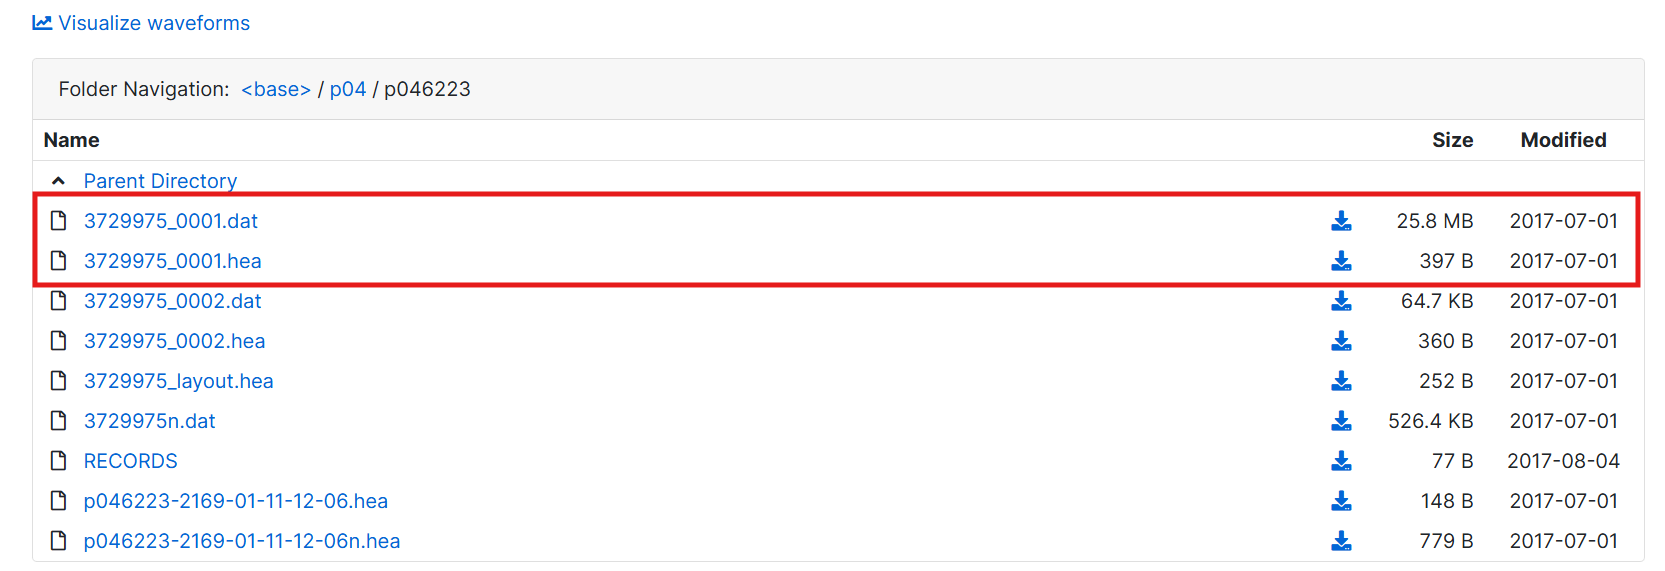

✍️Tracez toutes les ondes à l'aide de plt.subplots, où tous les signaux sont affichés et étiquetés. Expliquez quels sont les canaux de cet enregistrement et quelles informations chacun d'entre eux contient.


In [ ]:
# Extraire les canaux PPG et ABP
ppg = record.p_signal[:, indice_ppg]  # Remplacer indice_ppg par le numéro de la colonne du canal PPG
abp = record.p_signal[:, indice_abp]  # Remplacer indice_abp par le numéro de la colonne du canal ABP

# Extraire le segment temporel de 30 à 40 seondes
# Remplacer indice_30sec et indice_40sec par les indices d'échantillons correspondants
ppg_seg30 = ppg[indice_30sec:indice_40sec]
abp_seg30 = abp[indice_30sec:indice_40sec]

# Axe temporel correspondant à ce segment
t_seg30 = np.arange(indice_30sec, indice_40sec) / fs

# Tracer les deux signaux sur la même échelle de temps
plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.plot(t_seg30, ppg_seg30)
plt.title("PPG (30–40 s)")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(t_seg30, abp_seg30)
plt.title("ABP (30–40 s)")
plt.ylabel("mmHg")
plt.xlabel("Temps (s)")
plt.tight_layout()
plt.show()



**✍️  1.2. Trouvez les valeur SBP and DBP a partier du signal ABP**

1.	Expliquez comment les valeurs SBP et DBP peuvent être extraites de l'ABP. Montrez-les sur la forme d'onde ABP. Écrivez un code pour trouver ces valeurs pour la forme d'onde ABP de 30 secondes et marquez-les sur la forme d'onde dans un graphique.

**👉 Remarque** : Ces valeurs doivent être utilisées comme cibles pour l'entraînement d'un modèle d'IA.


**💡 La fonction** `scipy.signal.find_peaks`

La fonction `find_peaks()` de la bibliothèque **SciPy** permet de trouver automatiquement **les pics (maximums locaux)** dans un signal.

🧠 Idée de base :

Un **pic** est un point du signal qui est plus grand que ses voisins.
Autrement dit, si on parcourt le signal point par point, un pic correspond à un **maximum local**.

`find_peaks(signal, height=?, distance=?, prominence=?)`
* `height` Amplitude minimale du pic (ignore les petits pics)
* `distance` Distance minimale entre deux pics (en nombre d’échantillons)
* `prominence` Mesure à quel point un pic ressort par rapport à son voisinage (plus la valeur est grande, plus le pic est isolé)
* `width` Largeur minimale d’un pic (utile pour ignorer les pics trop étroits)

In [ ]:
from scipy.signal import find_peaks

In [ ]:
# --- Détection des pics (SBP) ---
peaks, _ = find_peaks(abp_seg30, distance=int('xx'), prominence='xx')

# --- Détection des minima (DBP) ---
mins, _ = find_peaks(-abp_seg30, distance=int('xx'), prominence='xx')


**✍️  1.3. Appliquer un filtre passe-bas de Butterworth**

1.	Appliquez un filtre Butterworth passe-bas d’ordre 2, avec des fréquences de coupure de 4 Hz, au signal PPG.
2.	Observez et expliquez comment le filtrage change la forme de l’onde pulsatile.


In [ ]:
from scipy.signal import butter, filtfilt

In [ ]:
# Conception du filtre Butterworth passe-bas (ordre 2, fc = 4 Hz)
fc = 4.0
nyq = 0.5 * fs
wn = fc / nyq              # fréquence de coupure normalisée
b, a = butter(2, wn, btype='low')

# Filtrage zéro-phase (pas de retard)
ppg_f = filtfilt(b, a, ppg)

### 1.4. Rééchantillonnage
1.	Sachant que le signal est initialement à **125 Hz**, proposez une fréquence d’échantillonnage minimale acceptable **après filtrage**. Justifiez votre réponse en fonction du **théorème de Nyquist**.
2.	Écris un code pour sous-échantillonner le signal à **10 Hz**. 
3.	Explique quelle quantité de redondance dans les données est éliminée par un tel sous-échantillonnage.

**💡 Aide** – Lorsque vous sous-échantillonnez, vous devez supprimer les fréquences supérieures à la nouvelle fréquence de Nyquist (la moitié du taux d'échantillonnage cible). La fonction `resample_poly` réalise cela automatiquement : il suréchantillonne par le facteur d'augmentation, applique un filtre FIR passe-bas (par défaut, un filtre sinc avec fenêtre de Kaiser), puis décime par le facteur de réduction.

Ainsi, si vous appelez simplement `resample_poly`, vous n'obtiendrez pas d'aliasing, même sans filtre explicite.

    # greatest common divisor (GCD)
    gcd = np.gcd(int(fs), target_fs)
    # Rational resampling factors (up/down)
    up = target_fs // gcd
    down = int(fs) // gcd
    # Resample the filtered signal
    resampled_signal = resample_poly(filtered_signal, up, down)
    # New time axis for resampled signal
    time_resampled = np.arange(len(resampled_signal)) / target_fs

**📖 Un peu de théorie** – Lorsque nous modifions la fréquence d'échantillonnage, il ne s'agit généralement pas d'un facteur entier net (par exemple, 125 Hz → 10 Hz). Pour obtenir exactement la nouvelle fréquence, nous procédons comme suit :
* Suréchantillonnage (insertion de zéros entre les échantillons) → cela affine la grille temporelle, ce qui nous permet d'« ajuster » la nouvelle fréquence d'échantillonnage souhaitée.
* Filtre passe-bas → filtre anti-aliasing qui supprime les composantes supérieures à la nouvelle Nyquist pour éviter le repliement spectral. Ce filtre lissera également les variations brusques ajoutées en raison des zéros ajoutés au signal.s
* Sous-échantillonnage (conserver chaque N-ième échantillon) → réduit le taux d'échantillonnage à la valeur cible.
* Ce processus de suréchantillonnage → filtrage → sous-échantillonnage est ce que fait en interne la fonction `resample_poly` (méthode polyphasée).


In [ ]:
from scipy.signal import resample_poly

In [ ]:
target_fs = 10 # objectif: 10 Hz

# Facteurs rationnels (polyphasé)
gcd = np.gcd(int(fs), target_fs)   # PGCD
up = target_fs // gcd              # facteur d'up-sampling
down = int(fs) // gcd              # facteur de décimation

# Rééchantillonner le signal filtré ppg_f
ppg_10hz = resample_poly(ppg_f, up, down)

# Axe temps rééchantillonné
t_10hz = np.arange(len(ppg_10hz)) / target_fs

# 💻 Exercice 2 – Normalisation des données (10%)

**⚖️ Pourquoi normaliser ?**
Les algorithmes d’IA fonctionnent mieux lorsque les données sont mises à la même échelle :
* amélioration de la convergence des modèles d’apprentissage,
* réduction de l’influence disproportionnée de certaines amplitudes,
* comparabilité directe entre différents signaux.

Ici, nous allons utiliser une **normalisation globale (Min–Max)** avec la fonction `MinMaxScaler` de `scikit-learn`.

Notez que nous n'utilisons pas ici la normalisation par variable (feature-wise), c'est-à-dire par colonne. La normalisation globale maintient une échelle commune et préserve les rapports d'amplitude entre les différents instants du signal PPG.

* On calcule un minimum et un maximum globaux sur l’ensemble du jeu d’entraînement.
* Ensuite, **tous les signaux (train + test)** sont transformés avec ces mêmes bornes → cela garantit que l’échelle de comparaison est cohérente.

**📂 Jeu de données (fichiers fournis)**

Pour éviter la complexité de l’accès direct au jeu MIMIC, nous vous fournissons un dataset déjà nettoyé et segmenté.
**Train**
* Data_Train_PPG.npy → (5000, 1250) : 5000 segments de 10 secondes de PPG (échantillonnés à 125 Hz → 1250 points par segment).
* Data_Train_Labels.npy → (5000, 2) : pour chaque segment, deux colonnes `[SBP, DBP]` correspondant à **la moyenne de la pression systolique et diastolique dans ce segment**.

**Test**
* Data_Test_PPG.npy → (500, 1250) : 500 segments de PPG (même format que ci-dessus).
* Data_Test_Labels.npy → (500, 2) : valeurs moyennes de `[SBP, DBP]` associées.

👉 Chaque exemple est donc une paire (PPG segment, `[SBP, DBP]`).

👉 Les données fournies (Data_Train_PPG.npy, Data_Train_Labels.npy, Data_Test_PPG.npy, Data_Test_Labels.npy) doivent être chargées avec la fonction `np.load` de **NumPy**.

1.	Chargez les fichiers fournis avec np.load :
* Data_Train_PPG.npy → matrice (5000, 1250)
* Data_Train_Labels.npy → matrice (5000, 2)
* Data_Test_PPG.npy → matrice (500, 1250)
* Data_Test_Labels.npy → matrice (500, 2)

2.	Nommez les variables comme suit (exigé pour homogénéité) :

    import numpy as np
  
    train_ppg   = np.load("Data_Train_PPG.npy")      # (5000, 1250)
  
    train_labels= np.load("Data_Train_Labels.npy")   # (5000, 2)
  
    test_ppg    = np.load("Data_Test_PPG.npy")       # (500, 1250)
  
    test_labels = np.load("Data_Test_Labels.npy")    # (500, 2)


In [ ]:
# Charger les fichiers .npy
train_ppg    = np.load("Data_Train_PPG.npy")      # (5000, 1250)
train_labels = np.load("Data_Train_Labels.npy")   # (5000, 2)
test_ppg     = np.load("Data_Test_PPG.npy")       # (500, 1250)
test_labels  = np.load("Data_Test_Labels.npy")    # (500, 2)

# Vérification rapide
print("Train PPG shape :", train_ppg.shape)
print("Train Labels shape :", train_labels.shape)
print("Test PPG shape :", test_ppg.shape)
print("Test Labels shape :", test_labels.shape)

**✍️ 2.1. Reshape des données**

1.	Considérons que vos données sont stockées sous la forme (N, L) où :
* N = nombre d'exemples de données (par ex. 5000)
* L = longueur temporelle (par ex. 1250 points)

2.	Pour appliquer la normalisation globale, il faut aplatir temporairement en un seul vecteur.

  `data_reshaped = data.reshape(-1, 1)  # data = train ou test`
  
👉 Vérifiez et rapportez les dimensions avant et après reshaping.


In [ ]:
# Reshape pour normalisation globale
train_ppg_reshaped = train_ppg.reshape(-1, 1)
test_ppg_reshaped  = test_ppg.reshape(-1, 1)

# Dimensions après reshape
print("\nAprès reshape :")
print("train_ppg_reshaped :", train_ppg_reshaped.shape)
print("test_ppg_reshaped  :", test_ppg_reshaped.shape)

* Avant le **reshape**, les données ont la forme (N, L) = (5000, 1250).
* Après le **reshape**, elles deviennent (N×L, 1) = (6 250 000, 1).

Ce format permet d’appliquer la **normalisation globale** sur toutes les valeurs du signal PPG à la fois, en utilisant un seul couple (min, max) commun à tout le jeu d’entraînement.

**✍️ 2.2. Fit et transformation**

1.	Fit le `MinMaxScaler` uniquement sur le jeu d’entraînement.
2.	Transformez ensuite à la fois train et test avec ce même scaler.
3.	Reshapez à nouveau les données transformées pour retrouver la forme originale des signaux.

👉 Expliquez pourquoi il est important d’utiliser les paramètres du train pour normaliser le test.

💡 Utilisez la fonction `MinMaxScaler()` de `scikit-learn` pour effectuer cette transformation.

    `label_scaler = MinMaxScaler()`
    
    `train_labels _scaled = label_scaler.fit_transform(train_labels)`


In [ ]:
!pip install scikit-learn
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Création du scaler Min–Max
ppg_scaler = MinMaxScaler()

# Fit UNIQUEMENT sur les données d'entraînement
ppg_scaler.fit(train_ppg_reshaped)

# Transformation train + test avec les mêmes bornes
train_ppg_scaled = ppg_scaler.transform(train_ppg_reshaped)
test_ppg_scaled  = ppg_scaler.transform(test_ppg_reshaped)

# Remise en forme (reshape inverse) pour retrouver la forme originale
train_ppg_s = train_ppg_scaled.reshape(train_ppg.shape)
test_ppg_s  = test_ppg_scaled.reshape(test_ppg.shape)

# Dimensions après remise en forme
print("\nAprès remise en forme :")
print("train_ppg_s :", train_ppg_s.shape)
print("test_ppg_s  :", test_ppg_s.shape)


**✍️ 2.4. Normalisation des Labels**

Nous avons deux labels : **SBP** et **DBP**.

Normaliser les labels est crucial pour optimiser l'apprentissage du modèle de régression. En ramenant les valeurs de SBP et DBP à une même échelle (par exemple, entre 0 et 1), le modèle n'est pas faussé par des différences de magnitude et peut se concentrer sur l'optimisation de la prédiction.

Ici, une normalisation globale n’est pas adaptée car SBP et DBP sont deux variables distinctes avec des gammes différentes.

👉 Nous utilisons donc une normalisation feature-wise (plus précisément label-wise) :
* chaque colonne de label (SBP et DBP) est normalisée séparément,
* le min et le max sont calculés sur tous les **examples d’entraînement** pour chaque colonne.

Ensuite, on **applique la même transformation aux jeux train et test** pour garder une échelle cohérente.

💡 Utilisez la fonction `MinMaxScaler()` de `scikit-learn` pour effectuer cette transformation.

⚠️Lors de l’évaluation finale des prédictions du modèle (ME, SDE, Bland–Altman), vous devez revenir aux valeurs en mmHg avec `inverse_transform` :

    Denormalized output in mmHg = label_scaler.inverse_transform(Model Prediction/Output)

In [ ]:
# Même traitement pour les labels SBP/DBP
label_scaler = MinMaxScaler()
train_labels_s = label_scaler.fit_transform(train_labels)
test_labels_s  = label_scaler.transform(test_labels)

# 💻 Exercice 3 – Construire un modèle hybride CNN/LSTM/MLP (20%)

Nous commençons par une architecture complète de **CNN, LSTM et FC (MLP)** afin d'obtenir plus facilement des résultats fiables. Dans les exercices suivants, nous mènerons des études d'ablation afin de vérifier comment **CNN** et **LSTM** fonctionnent séparément, et nous analyserons l'impact du rééchantillonnage et de la normalisation des données.

**🏗️ Architecture du modèle : Un système hybride puissant**

Notre modèle est conçu pour tirer le meilleur parti de la nature de nos données, qui sont à la fois des séries temporelles et des signaux complexes. C'est pourquoi nous utilisons une architecture hybride, combinant trois types de réseaux de neurones pour des rôles bien précis :

1.	**Le Réseau de Neurones Convolutif (CNN)** : Le **détecteur de motifs**. La première partie de notre modèle est un **CNN (Convolutional Neural Network)**. Son rôle est d'analyser le signal PPG comme s'il s'agissait d'une petite **image unidimensionnelle**. Il parcourt le signal pour détecter et extraire automatiquement des caractéristiques locales importantes, comme les pics, les pentes, ou la forme des ondes. Pensez-y comme un outil capable de repérer les motifs essentiels qui définissent le signal, sans que nous ayons à les lui indiquer à l'avance.
2.	**Le Réseau Long Short-Term Memory (LSTM)** : Le **garde de la mémoire**. Les signaux PPG et la pression artérielle sont des séries temporelles. Cela signifie que l'information à un instant donné dépend de ce qui s'est passé juste avant. Un simple CNN ne pourrait pas capturer cette dynamique temporelle. C'est là qu'intervient le **LSTM (Long Short-Term Memory)**. Ce type de réseau est une variante de **RNN (Recurrent Neural Network)** qui excelle dans l'analyse des séquences. Il mémorise les informations importantes sur le long terme et les utilise pour contextualiser les données en cours. L'ajout d'un LSTM permet à notre modèle de comprendre comment la forme de l'onde évolue dans le temps, ce qui est crucial pour prédire la pression artérielle.
3.	**Le Réseau Fully Connected (FC) / Perceptron Multi-Couches (MLP)** : Une fois que le CNN a extrait les caractéristiques clés et que le LSTM a capturé les dépendances temporelles, les informations sont envoyées à un réseau Fully Connected (FC), également connu sous le nom de Perceptron Multi-Couches (MLP). Ce dernier bloc agit comme une couche de décision finale. Il prend les caractéristiques apprises par les couches précédentes et les combine pour produire la prédiction finale de la pression artérielle (SBP et DBP). C'est la dernière étape qui "traduit" les caractéristiques complexes en une valeur numérique simple pour notre tâche de régression.

En combinant ces trois éléments, le modèle peut d'abord identifier les motifs du signal, puis comprendre la dynamique de ces motifs sur une période de temps, et enfin utiliser ces informations pour faire une prédiction précise.

⚙️ Données d’entrée = segments PPG de 10 secondes à 125 Hz → 1250 points par segment, avec 1 canal. Forme d’entrée = (1250, 1).


**✍️ Consignes**

Vous allez construire un modèle **Keras** **pas à pas**, en reprenant exactement les blocs définis ci-dessous.

👉 Pour garder le code clair et réutilisable, vous devez **définir une fonction** qui construit et retourne le modèle (plutôt que de l’écrire “en dur” dans une cellule). Cela permet, plus tard, d’appeler simplement `model = build_cnn_lstm_mlp ((1250,1), num_outputs=2)` pour générer à nouveau le modèle :

    def build_cnn_lstm(input_shape, num_outputs=2):
    …
    Ici, vous devez créer le modèle en suivant les instructions suivantes, de 1 à 10.
    …
    return model

1.	**Entrée** :
* Input(shape=(1250,1), name="PPG_input")
2.	**Bloc initial CNN** :
* Conv1D(64, kernel_size=7, strides=2, padding="same", activation="relu")
* BatchNormalization()
* MaxPooling1D(pool_size=3, strides=2, padding="same")
3.	**Bloc 1** :
* Deux convolutions Conv1D(64, kernel_size=3, padding="same", activation="relu"), chacune suivie de BatchNormalization()
4.	**Bloc 2** :
* Conv1D(128, 3, strides=2, padding="same", activation="relu") + BatchNorm
* Conv1D(128, 3, padding="same", activation="relu") + BatchNorm
5.	**Bloc 3** : identique au bloc 2 mais avec **256 filtres**.
6.	**Bloc 4** : identique au bloc 2 mais avec **512 filtres**.
7.	**LSTM** :
* LSTM(128, return_sequences=True)
* LSTM(128, return_sequences=True)
* LSTM(64, return_sequences=False)
8.	**Fully Connected (Dense)** :
* Dense(1024, activation="relu")
* Dense(1024, activation="relu")
* Dense(512, activation="relu")
* Dense(256, activation="relu")
9.	**Sortie** :
* Dense(2, activation=None) → prédire SBP et DBP
10.	**Construire un modèle factice** :

        model = Model(inputs=inputs, outputs=outputs, name="CNN_LSTM_MLP")
        model.summary()

👉 Résultat attendu : un modèle CNN_LSTM avec 4 blocs CNN, 3 LSTM et 4 couches Dense, dont la sortie finale est 2 valeurs (SBP, DBP).


**📊 Questions**


1.	Quelle est **la taille d’entrée** du modèle ?
2.	Quelle est la taille de sortie du **CNN** (avant le LSTM) ?
3.	Quelle est la taille d’entrée du **LSTM** ? 
4.	Quelle est la taille de sortie du **LSTM** (avant le Dense) ?

La sortie du CNN est de forme (T, D).

    a) Dans cette représentation, quel est le rôle de **T** : est-ce le nombre de pas de temps ou le nombre de features ?
    b) Quel est le rôle de **D** : est-ce le nombre de pas de temps ou le nombre de features ?
    c) Expliquez en vos mots ce que cela signifie concrètement :
        - Combien de “tranches temporelles” le LSTM reçoit-il ?
        - Quelle information contient chaque tranche ?
    d) Considérez séparément ces deux modifications du CNN, sans changer le reste de l’architecture :
        - Moins de filtres dans le dernier bloc convolutionnel (strides/pooling inchangés).
        - Moins de sous-échantillonnage temporel (par ex. supprimer un pooling ou mettre stride=1 dans une conv).
    Pour chaque cas :
        - Que change la forme d’entrée du LSTM (nombre de pas de temps vs dimension des features) ?
        - Quel impact probable sur la difficulté d’apprentissage, la capacité du modèle et le risque d’over/underfitting ?

5.  Quelle est la taille finale de sortie du modèle ?
6.	Expliquez pourquoi la fonction d'activation de sortie est sélectionnée comme « None/Aucune » ?


In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

### 🧱 Explication de l’architecture du modèle CNN–LSTM–MLP

* La commande `Input(shape=input_shape)` définit la forme du signal que le modèle doit recevoir..

* Création du point d’entrée du réseau, nommé "PPG_input". C’est à partir de cet objet que toutes les couches seront connectées.

**🧩 Qu’est-ce que Conv1D ?**

* `Conv1D` signifie **Convolution 1D**, utilisée pour traiter des **signaux temporels** (comme le PPG, l’ECG, l’audio, etc.).
* Elle fait glisser une **petite fenêtre (kernel)** le long du signal, et calcule une **combinaison pondérée** des valeurs locales pour extraire des motifs (patterns).
* Chaque filtre apprend un motif spécifique (ex. un pic de battement, une pente ascendante, une oscillation...)

`x = Conv1D(64, kernel_size=7, strides=2, padding="same", activation="relu")(inputs)`
* 64 nombre de filtre
* kernel_size = 7 : longueur du filtre, la fenêtre d’observation glissante couvre 7 échantillons successifs du signal.
* strides=2 : pas du déplacement, le filtre avance de 2 points à chaque fois → on réduit la taille du signal (sous-échantillonnage).
* padding="same" : type de remplissage, on ajoute des zéros au bord du signal pour conserver la même longueur après convolution.
* activation="relu" : fonction d'activation, introduit la non-linéarité.

**🧠 Qu’est-ce que BatchNormalization ?**

* `BatchNormalization` : normalise les activations entre les couches pour stabiliser l’apprentissage.
* Elle prend les valeurs de sortie de la couche précédente (x), et les normalise (c’est-à-dire les recentre et les met à la même échelle)

**🧩 Que fait MaxPooling1D ?**

* `MaxPooling1D` : est une couche de sous-échantillonnage (pooling) utilisée après des convolutions.
* Son rôle: Réduire la taille du signal (en longueur temporelle) tout en conservant les informations les plus importantes

* `x = MaxPooling1D(pool_size=3, strides=2, padding="same")(x)`
* pool_size=3 : Taille de la fenêtre de pooling, regroupe 3 valeurs successives à la fois.
* strides=2 : Pas de déplacement, la fenêtre avance de 2 échantillons → on réduit la longueur du signal.
* padding="same" : Tupe de remplissage, ajoute des zéros au bord si nécessaire pour garder la longueur compatible.

**🧠 Pourquoi ajouter un LSTM après un CNN ?**

* Le CNN extrait des caractéristiques locales du signal PPG (forme des ondes, amplitude, pente, etc.).
* Le LSTM (Long Short-Term Memory) est conçu pour analyser ces relations temporelles, c’est-à-dire comment les motifs extraits par le CNN évoluent dans le temps.

`x = LSTM(128, return_sequences=True)(x)`
* 128 : à chaque pas de temps, le LSTM produit un vecteur de 128 valeurs (caractéristique temporelle apprise).
* return_sequences=True : le LSTM garde tous les états à chaque instant t.
* return_sequences=False : le LSTM ne garde que le dernier état (résumé global de la séquence)

**🧩 Qu’est-ce qu’un MLP ?**

Le MLP (Multi-Layer Perceptron) est une suite de couches entièrement connectées (Fully Connected layers).
Cela veut dire que chaque neurone est relié à tous les neurones de la couche précédente.

* Dans Keras, une couche `Dense` correspond à une couche “Fully Connected”.
* Pas d’activation (`None`) → la sortie peut prendre toute valeur réelle (utile pour la régression)

**Le modèle**

L’instruction `model = Model(inputs=inputs, outputs=outputs, name="CNN_LSTM_MLP")` construit l’architecture complète du modèle en reliant explicitement le tenseur d’entrée au tenseur de sortie à travers toutes les couches intermédiaires.

**🧠 model.summary()**

Cette méthode Keras affiche un résumé lisible de ton modèle :
* les couches dans l’ordre,
* les tailles des tenseurs à chaque étape,
* le nombre de paramètres entraînables (poids + biais).


In [ ]:
def build_cnn_lstm_mlp(input_shape, num_outputs=2):
    
    inputs = Input(shape=input_shape, name="PPG_input")

    # Bloc initial CNN
    x = Conv1D(64, kernel_size=7, strides=2, padding="same", activation="relu")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding="same")(x)

    # Bloc 1
    x = Conv1D(64, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv1D(64, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    # Bloc 2
    x = Conv1D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv1D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)

    # Bloc 3
    # identique au bloc 2 mais avec 256 filtres
    #
    #
    #

    # Bloc 4
    # identique au bloc 2 mais avec 512 filtres
    #
    #
    #

    # LSTM
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(64, return_sequences=False)(x)

    # MLP | FC
    x = Dense(1024, activation="relu")(x)
    x = Dense(1024, activation="relu")(x)
    x = Dense(512, activation="relu")(x)
    x = Dense(256, activation="relu")(x)

    # Sortie
    outputs = Dense(num_outputs, activation=None)(x)

    model = Model(inputs=inputs, outputs=outputs, name="CNN_LSTM_MLP")
    return model

# Construire un modèle factice
model = build_cnn_lstm_mlp(input_shape=(1250,1), num_outputs=2)
model.summary()
